In [150]:
import networkx as nx
network = nx.read_graphml("celebrities_clean_without_content.graphml")

Defining our different eras which we will investigate

In [151]:
periods = [
    (-float('inf'), 30, "Before Christ"),
    (30, 476, "Classical Era"),
    (476, 1450, "Middle Ages"),
    (1450, 1760, "Early Modern Era"),
    (1760, 1840, "Industrial Era"),
    (1840, 1945, "Wartime Era"),
    (1945, 2025, "Post-War Era"),
    (2025, float('inf'), "Unknown")
]

In [152]:
# periods = [
#     (-float('inf'), 30, "Before Christ"),
#     (30, 325, "Early Christianity"),
#     (325, 1054, "Nicaea to East–West Schism"),
#     (1054, 1517, "East–West Schism to Reformation"),
#     (1517, 1760, "Reform ation to industrial era"),
#     (1760, 1840, "industrial era"),
#     (1840, 1945, "Wartime"),
#     (1945, 2000, "Post war"),
#     (2000, 2025, "21st century")
# ]

We create subgraphs for each of our eras from the main graphs using networkx. We define a person being included in an era if their birthyear is within an era. This way each person is only present in one single era.

In [153]:
era_subgraphs = {}
for start, end, label in periods:

    subgraph = network.subgraph([n for n, attr in network.nodes(data=True) if (attr.get("birthyear") <= end) and attr.get("birthyear") >= start])
    print(f"Period: {label}, Number of nodes: {subgraph.number_of_nodes()}")
    era_subgraphs[label] = subgraph

Period: Before Christ, Number of nodes: 534
Period: Classical Era, Number of nodes: 308
Period: Middle Ages, Number of nodes: 876
Period: Early Modern Era, Number of nodes: 889
Period: Industrial Era, Number of nodes: 751
Period: Wartime Era, Number of nodes: 4051
Period: Post-War Era, Number of nodes: 3982
Period: Unknown, Number of nodes: 0


In [154]:
def node_by_name(G, name):
    for n in G.nodes:
        if getattr(n, "name", None) == name:
            return n

Next we collect all of the Poese corresponding to our era definitions. The filtering is done with the title (in the name) and occupation as RELIGIOUS FIGURE

In [155]:
popes_in_periods = {}
for period, subgraph in era_subgraphs.items():
    pope_nodes = [
        (n, attr) for n, attr in subgraph.nodes(data=True)
        if isinstance(attr.get("Name"), str) and "Pope" in attr.get("Name") and attr.get("occupation") == "RELIGIOUS FIGURE"
    ]
    popes_in_periods[period] = pope_nodes
    print(f"Period: {period}, Number of popes: {len(pope_nodes)}")


Period: Before Christ, Number of popes: 4
Period: Classical Era, Number of popes: 50
Period: Middle Ages, Number of popes: 157
Period: Early Modern Era, Number of popes: 35
Period: Industrial Era, Number of popes: 6
Period: Wartime Era, Number of popes: 9
Period: Post-War Era, Number of popes: 0
Period: Unknown, Number of popes: 0


In [156]:
import networkx as nx

def get_undirected_neighbors(node, network):
    """
    Returns a list of neighbors for a specific node, treating all edges 
    as undirected regardless of the graph type.
    """
    # Check if the node exists to avoid generic errors later
    if node not in network:
        raise ValueError(f"Node {node} not found in the network.")

    if network.is_directed():

        in_neighbors = set(network.predecessors(node))
        out_neighbors = set(network.successors(node))
        return list(in_neighbors | out_neighbors)
    else:
        return list(network.neighbors(node))

In [157]:
import os

In [158]:
def get_wikilink_content(node_id, network, folder_path="wikipages"):
    """
    Finds a node by ID, retrieves its 'NameURL' attribute, and reads 
    the corresponding text file from the specified folder.
    
    Args:
        node_id: The ID of the node to look up.
        network: The NetworkX graph object.
        folder_path: The directory where text files are stored (default: 'wikilinks').
        
    Returns:
        str: The content of the text file.
        
    Raises:
        ValueError: If node is not found or NameURL is missing.
        FileNotFoundError: If the text file does not exist.
    """
    
    # Check if node exists in the network
    if node_id not in network:
        raise ValueError(f"Node ID '{node_id}' not found in the network.")
    
    # Get the node's attributes
    node_data = network.nodes[node_id]
    
    # Retrieve the NameURL attribute
    name_url = node_data.get("NameURL")
    
    if not name_url:
        raise ValueError(f"Node '{node_id}' does not have a 'NameURL' attribute.")
    
    # Construct the file path
    filename = f"{name_url}.txt"
    file_path = os.path.join(folder_path, filename)
    
    # Read and return the file content
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            return f.read()
    except FileNotFoundError:
        print(f"Warning: Skipped missing file: {filename}")
        return None  # Return None instead of crashing
    except IOError as e:
        raise IOError(f"Error reading file {file_path}: {e}")


As now we have the popes sorted within our era buckets, we start preparing the texts to the wordclouds. Our approach is to get a wordcloud around each era of popes. We use the network to get the immediate connections to each pope and then gather their wikipedia texts. These are goinf to be used to generate the wordclouds for each era. The reason for this approach is that contrary to only selecting the wikipedia texts of the popes which are quite similar even across eras, we instead look at the articles of the people associated with them which in our hopes would give a better impression on how the popes are embedded into each era.

Wordcloud preparation

In [159]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [160]:
# Download necessary NLTK data
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')

# Initialize lemmatizer and stop words
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\boton\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


The wikipedia texts need to be cleaned and tokenized. For this we have taken our approach from one of the previous submissions and refined it. The regular expressions remove html tags, comments and most fields that contain metadata.

In [161]:
import re
import string

from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords


stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_and_tokenize(text):
    
    # Remove Refs/Citations first (content inside <ref> is usually not main text)
    text = re.sub(r'<ref[^>]*>.*?</ref>', '', text, flags=re.DOTALL)
    
    # Remove HTML comments
    text = re.sub(r'', '', text, flags=re.DOTALL)
    
    # Remove URLs (keep this aggressive as per your request)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    
    # Remove File/Image/Category links completely (e.g., [[File:Image.jpg]])
    text = re.sub(r'\[\[(File|Category|Image):[^\]]+\]\]', '', text, flags=re.IGNORECASE)

    # Handle Wikilinks: [[Target|Display]] -> keep "Display". [[Target]] -> keep "Target"
    # This regex looks for optional text before a pipe |, and captures what follows.
    text = re.sub(r'\[\[(?:[^|\]]*\|)?([^\]]+)\]\]', r'\1', text)

    # Remove Templates.
    text = re.sub(r'\{\{[^}]+\}\}', '', text)
    
    # Remove remaining HTML tags but keep content between them
    text = re.sub(r'<[^>]+>', ' ', text)

    
    # Lowercase
    text = text.lower()
    
    # Handle Punctuation
    text = re.sub(f'[{re.escape(string.punctuation)}]', ' ', text)
    
    # Remove extra whitespace created by replacements
    text = re.sub(r'\s+', ' ', text).strip()

    
    tokens = text.split()
    cleaned_tokens = []
    
    for token in tokens:
        # Skip stop words
        if token in stop_words:
            continue
        
        # Skip digits/special chars (keep only alphabetic)
        if not token.isalpha():
            continue
            
        # Adjusted Length filter
        if len(token) < 2: 
            continue
        if len(token) > 20:
            continue
            
        # Lemmatize
        lemmatized = lemmatizer.lemmatize(token)
        cleaned_tokens.append(lemmatized)

    return cleaned_tokens

Our initial approach was to create wordclouds from the raw frequencies of words appearing in the concatenated wikipedia texts. The results of this approach included plenty of similarities and did not capture the characteristics of the different eras. Additionally, some of the most common words were 'also' and 'would' which are equally present in almost all texts and hold no specific meaning to an era. Because of this as a next experiment we introduced the TF-IDF based approach which was introduced in one of the lectures. Our way of calculating the scores is the following:

## TF–IDF Calculation Formulas

TF–IDF measures how important a word is within a document (all texts aggregated for an era) compared to all documents (all era texts).

- **t** = a term (word)
- **d** = a specific document
- **D** = the full set of documents
- **N** = total number of documents (`len(D)`)
- **count(t, d)** = number of times term *t* is present in document *d*
- **total_terms(d)** = total number of tokens in document *d*
- **DF(t)** = number of documents that contain term *t* (document frequency)
- **min_df** = minimum number of documents a term must appear in (filter)

**Term Frequency (TF):**
$$
\text{TF}(t,d) = \frac{\text{count}(t,d)}{\text{total\_terms}(d)}
$$

**Document Frequency (DF):**
$$
\text{DF}(t) = |\{ d \in D : t \in d \}|
$$

**IDF (computed only when } \text{DF}(t) \ge \text{min\_df} \text{):**
$$
\text{IDF}(t) = \ln\left( \frac{N}{\text{DF}(t)} \right)
$$

**TF–IDF Weight:**
$$
\text{TF-IDF}(t,d) = \text{TF}(t,d) \times \text{IDF}(t)
$$


In [162]:
import math
from collections import Counter
from typing import Dict, Any

def compute_tf_idf(documents_dict: Dict[Any, str], min_df: int = 2) -> Dict[Any, Dict[str, float]]:

    n_documents = len(documents_dict)
    
    # Stores (term_counts, total_tokens) per document
    doc_data = {} 
    
    # Tracks how many documents contain a specific term
    global_doc_freq = Counter()

    # Tokenize and Count
    for doc_id, text in documents_dict.items():
        tokens = clean_and_tokenize(text)
        
        if not tokens:
            doc_data[doc_id] = (Counter(), 0)
            continue

        term_counts = Counter(tokens)
        doc_data[doc_id] = (term_counts, len(tokens))
        
        # Update document frequency (set ensures we count presence only once per doc)
        global_doc_freq.update(term_counts.keys())

    # Calculate IDF (Pre-computation)
    idf_lookup = {
        term: math.log(n_documents / df)
        for term, df in global_doc_freq.items()
        if df >= min_df
    }

    tf_idf_matrix = {}

    for doc_id, (term_counts, total_terms) in doc_data.items():
        doc_vector = {}
        
        # Only process if document is not empty
        if total_terms > 0:
            for term, count in term_counts.items():
                # Only calculate if term exists in our filtered IDF lookup
                if term in idf_lookup:
                    tf = count / total_terms
                    idf = idf_lookup[term]
                    doc_vector[term] = tf * idf
        
        tf_idf_matrix[doc_id] = doc_vector

    return tf_idf_matrix

In [163]:
def filter_and_update_corpus(documents_dict, max_doc_freq=0.6):
    """
    1. Tokenizes all documents.
    2. Identifies words appearing in > X% of documents (corpus-specific stops).
    3. Removes those words from the texts.
    4. Returns a NEW documents_dict with the cleaned text.
    """
    from collections import Counter
    
    # Temporary storage to avoid tokenizing twice
    tokenized_docs = {} 
    doc_counts = Counter()
    total_docs = len(documents_dict)
    
    print("Analyzing corpus for frequent terms...")
    
    # Step 1: Tokenize and Count
    for doc_id, text in documents_dict.items():
        # We use use_bigrams=False here because we want to filter base words 
        # (e.g., remove "pope" before it becomes "pope_gregory")
        tokens = clean_and_tokenize(text)
        
        # Update global counts (using set so we count document frequency, not term frequency)
        unique_tokens = set(tokens)
        doc_counts.update(unique_tokens)
        
        # Store tokens for Step 3
        tokenized_docs[doc_id] = tokens

    # Step 2: Identify the "Ignore List"
    ignore_set = {term for term, count in doc_counts.items() 
                  if (count / total_docs) > max_doc_freq}
    
    print(f"Auto-detected {len(ignore_set)} specific stopwords (appearing in >{int(max_doc_freq*100)}% of docs).")
    if len(ignore_set) > 0:
        print(f"Examples removed: {list(ignore_set)[:5]}")

    # Step 3: Rebuild the dictionary
    cleaned_documents = {}
    
    for doc_id, tokens in tokenized_docs.items():
        # Filter out the bad words
        filtered_tokens = [t for t in tokens if t not in ignore_set]
        
        # Join back into a string so it remains compatible with your existing pipeline
        # which expects {doc_id: "text string"}
        cleaned_documents[doc_id] = " ".join(filtered_tokens)

    return cleaned_documents

In [164]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter

def create_wordcloud_from_tokens(tokens, title="Word Cloud", colormap='viridis'):

    if not tokens or len(tokens) == 0:
        print("Cannot generate WordCloud: Input token list is empty.")
        return
    tokens = [str(t).strip() for t in tokens if '\n' not in str(t)]

    word_counts = Counter(tokens)

    # Configure WordCloud
    wc = WordCloud(
        width=1200, 
        height=800,
        background_color='white',
        colormap=colormap,
        max_words=150,
        relative_scaling=0.5,
        min_font_size=10
    ).generate_from_frequencies(word_counts)

    # Plotting
    plt.figure(figsize=(12, 10))
    plt.imshow(wc, interpolation='bilinear')
    
    # Styling
    plt.title(title, fontsize=16, fontweight='bold', pad=20)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

In [165]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter

def create_tfidf_wordcloud(tf_idf_matrix, doc_id=None, title="TF-IDF Word Cloud", colormap='viridis'):
    """
    Generates a word cloud from TF-IDF scores.
    """
    if doc_id is not None:
        if doc_id not in tf_idf_matrix:
            print(f"Error: Document ID '{doc_id}' not found in matrix.")
            return
        weights = tf_idf_matrix[doc_id]
        if not title: title = f"TF-IDF Cloud: {doc_id}"
        
    # sum scores across ALL documents to find globally important terms
    else:
        weights = Counter()
        for doc_vec in tf_idf_matrix.values():
            weights.update(doc_vec)

    # Safety Check
    if not weights:
        print("Cannot generate WordCloud: Input weight dictionary is empty.")
        return

    # Configure WordCloud
    # We use generate_from_frequencies because we already have the calculated weights
    wc = WordCloud(
        width=1200, 
        height=800,
        background_color='white',
        colormap=colormap,
        max_words=150,
        relative_scaling=0.5,
        min_font_size=10
    ).generate_from_frequencies(weights)

    # 4. Plotting
    plt.figure(figsize=(12, 10))
    plt.imshow(wc, interpolation='bilinear')
    
    # Styling
    plt.title(title, fontsize=16, fontweight='bold', pad=20)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

In [166]:
def get_wordcloud_of_pope_era(era):
    jumbo_tokens = []
    target_popes = popes_in_periods[era]
    for pope in target_popes:
        neighbors = get_undirected_neighbors(pope[0], network)
        for n in neighbors:
            relevant_tokens = clean_and_tokenize(get_wikilink_content(n, network))
            jumbo_tokens += relevant_tokens

    create_wordcloud_from_tokens(jumbo_tokens, title=f"Keywords for {era} era popes", colormap='viridis')


In [167]:
def visualize_all_pope_eras(popes_in_periods, network):
    """
    Combines text for all eras.
    Computes TF-IDF to find characteristic terms per era.
    Generates a word cloud for each era.
    """
    era_documents = {}

    print("Gathering Data")
    # Loop through all available eras
    for era, popes in popes_in_periods.items():
        print(f"Processing era: {era}...")
        
        # collect all raw text
        era_raw_text_chunks = []
        
        for pope in popes:

            pope_id = pope[0]
            
            neighbors = get_undirected_neighbors(pope_id, network)
            
            for n in neighbors:
                # Get the raw content string
                content = get_wikilink_content(n, network)
                if content:
                    era_raw_text_chunks.append(str(content))
        
        # Join all text chunks to form one "Document" representing the whole Era
        era_documents[era] = " ".join(era_raw_text_chunks)

    print("\nComputing TF-IDF")

    era_documents = filter_and_update_corpus(era_documents, max_doc_freq=0.7)

 
    # Terms appearing in ALL eras (high Document Frequency) should get a lower score
    tf_idf_matrix = compute_tf_idf(era_documents, min_df=1)

    for era, vec in list(tf_idf_matrix.items()):
        if not vec:
            continue
        max_v = max(vec.values())
        if max_v > 0:
            tf_idf_matrix[era] = {k: v / max_v for k, v in vec.items()}
            
    print("\nGenerating Visualizations")
    for era in era_documents.keys():
        create_tfidf_wordcloud(
            tf_idf_matrix, 
            doc_id=era, 
            title=f"Distinctive Keywords: {era} Era",
            colormap='viridis'
        )

In [105]:
import os

In [106]:
get_wordcloud_of_pope_era("Classical Era")

KeyError: 'Classical Era'

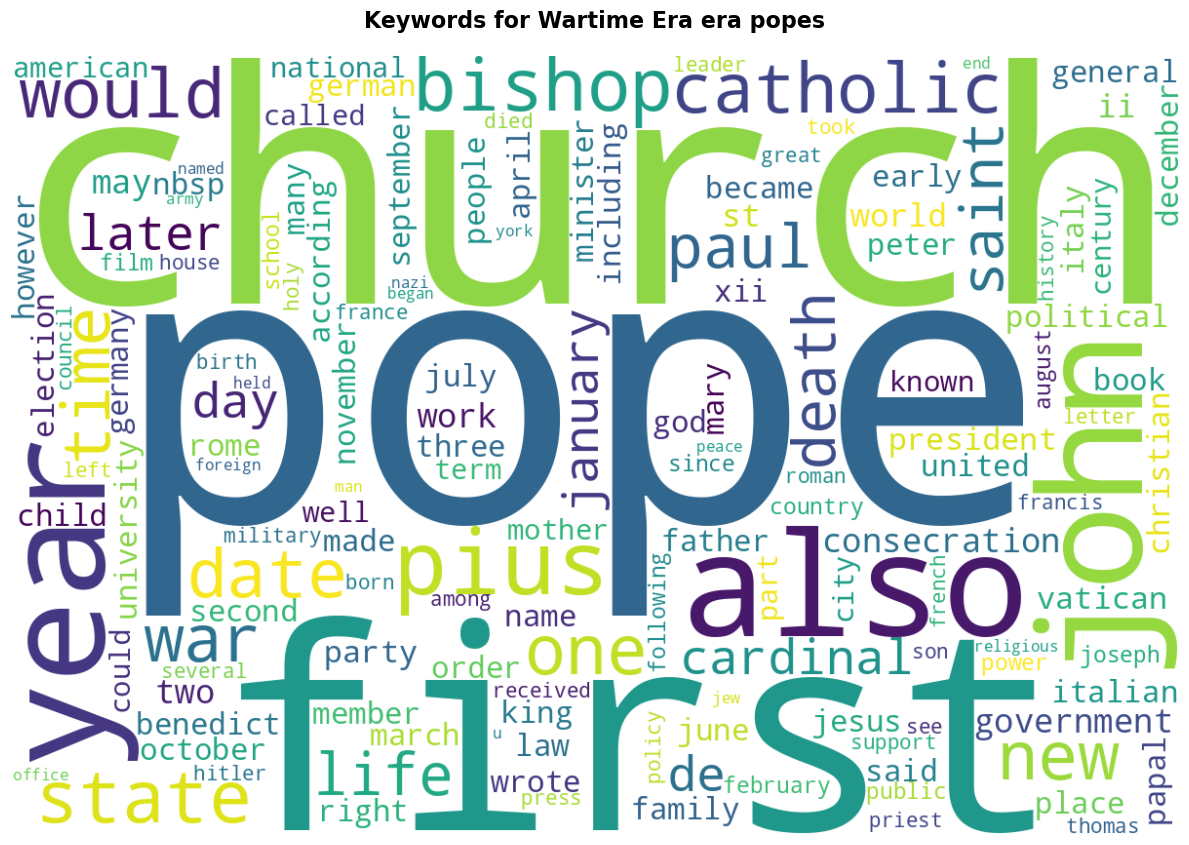

In [ ]:
get_wordcloud_of_pope_era("Wartime Era")

Gathering Data
Processing era: Before Christ...
Processing era: Classical Era...
Processing era: Middle Ages...
Processing era: Early Modern Era...
Processing era: Industrial Era...
Processing era: Wartime Era...
Processing era: Post-War Era...
Processing era: Unknown...

Computing TF-IDF
Analyzing corpus for frequent terms...
Auto-detected 7541 specific stopwords (appearing in >70% of docs).
Examples removed: ['abortive', 'foiled', 'oppressive', 'vi', 'propose']

Generating Visualizations


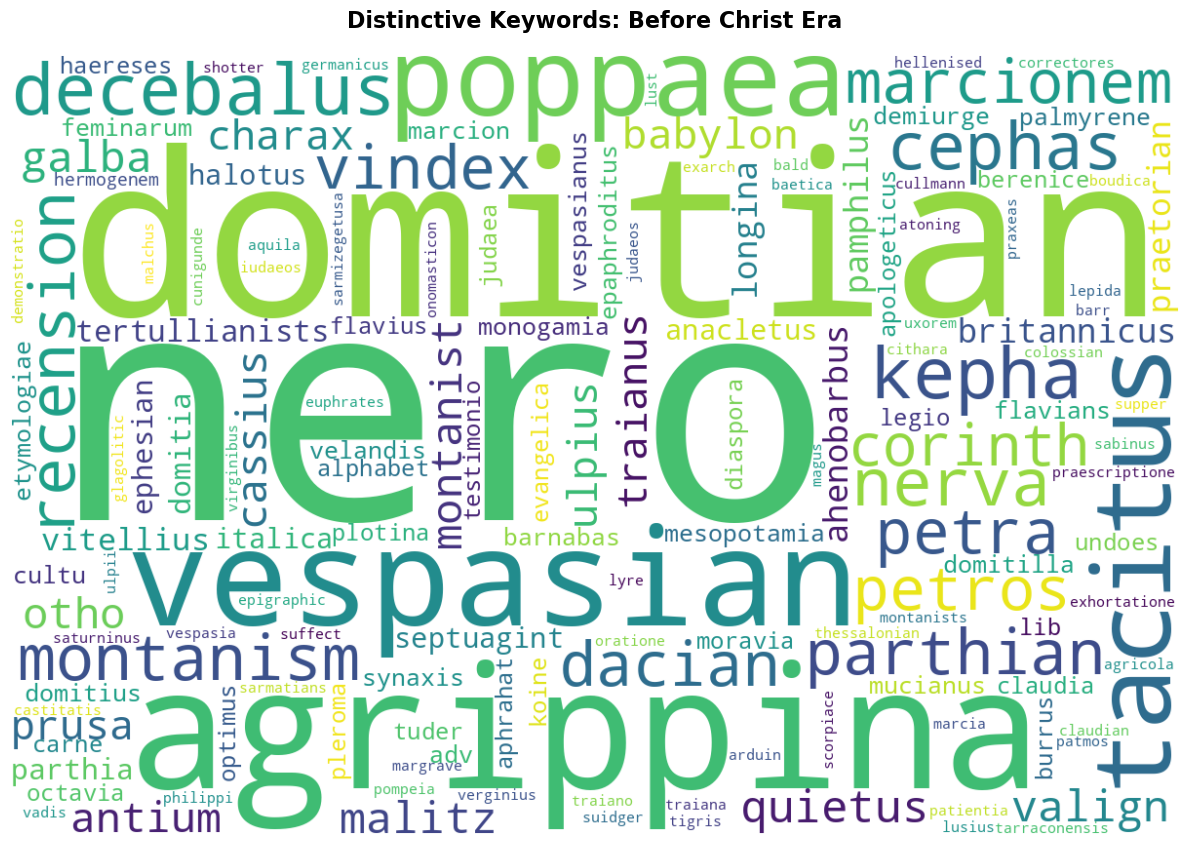

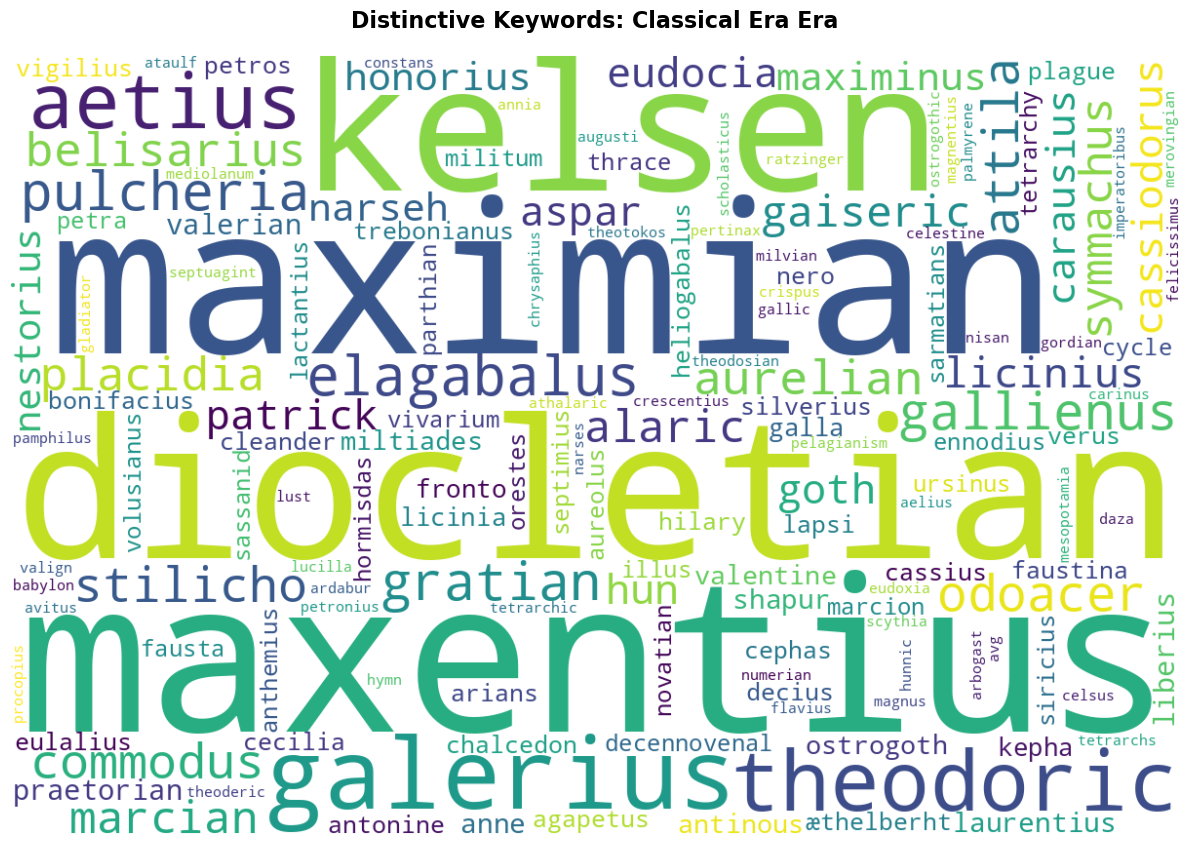

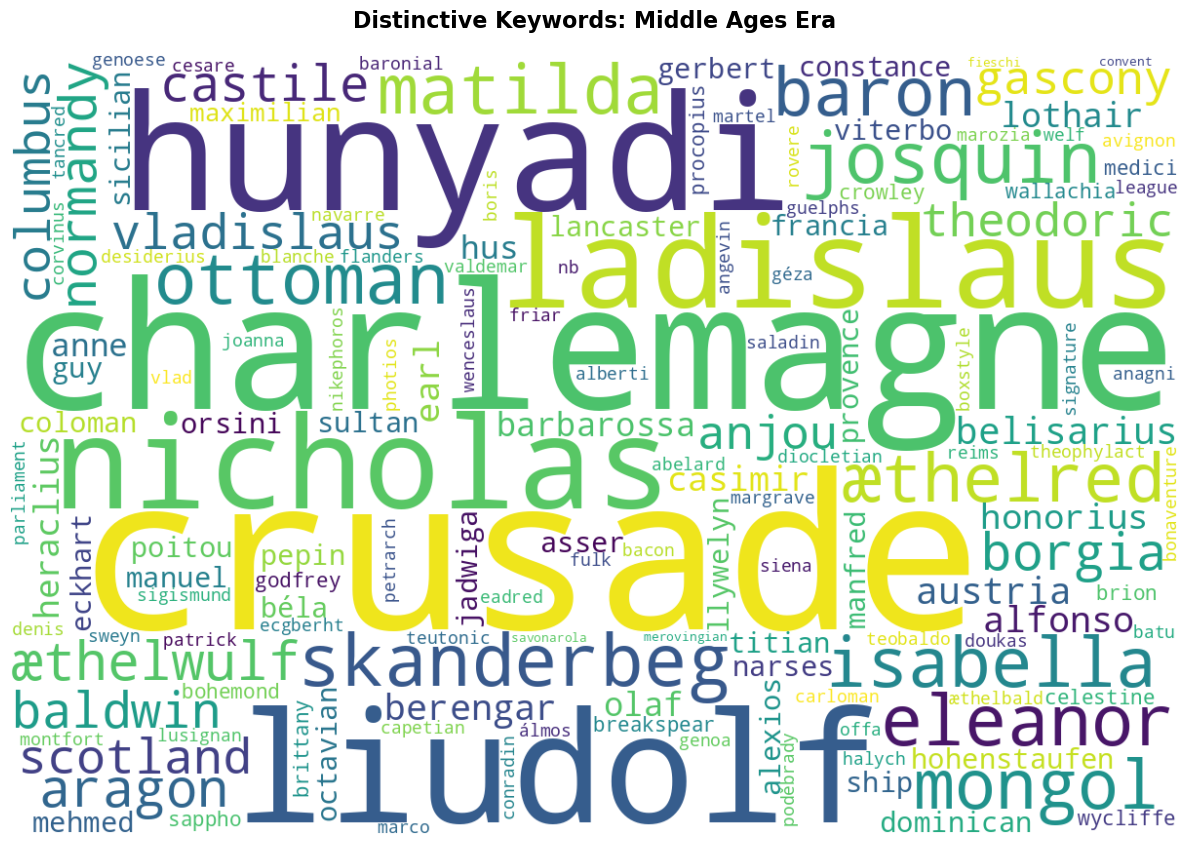

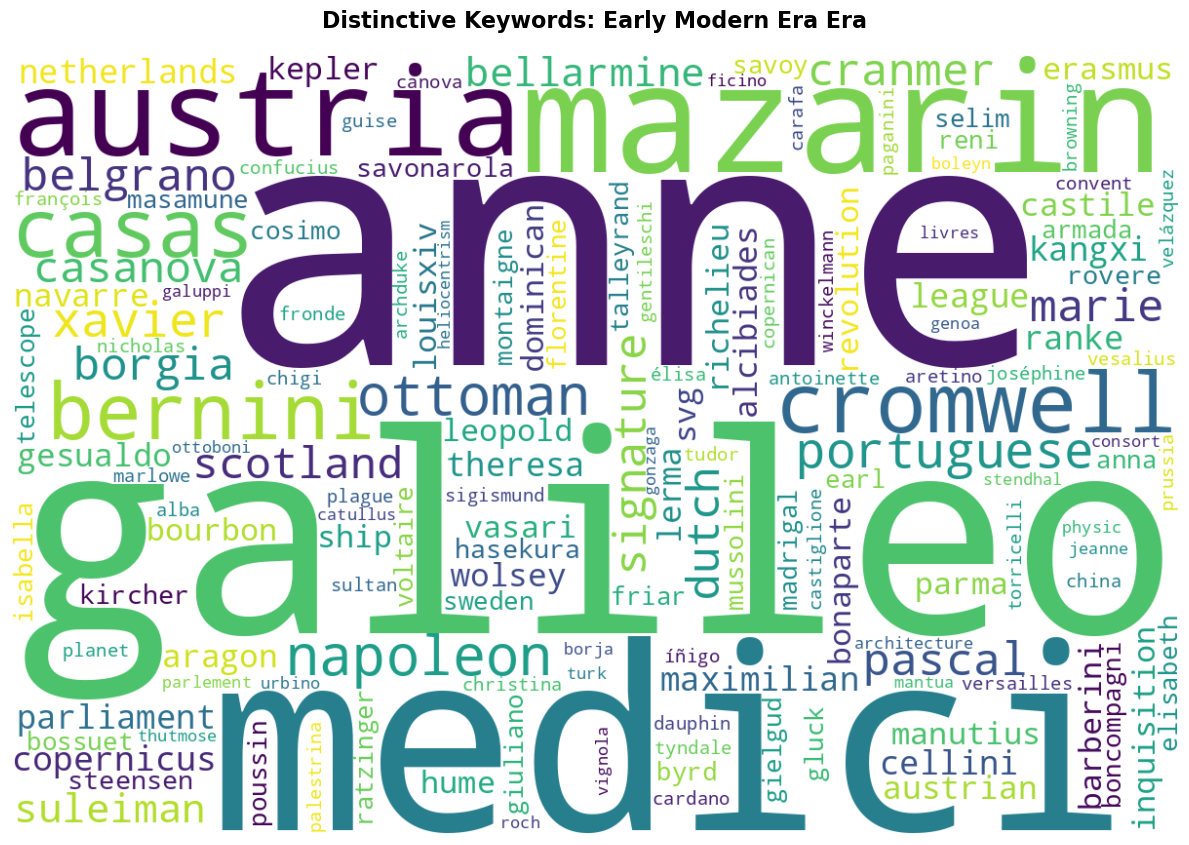

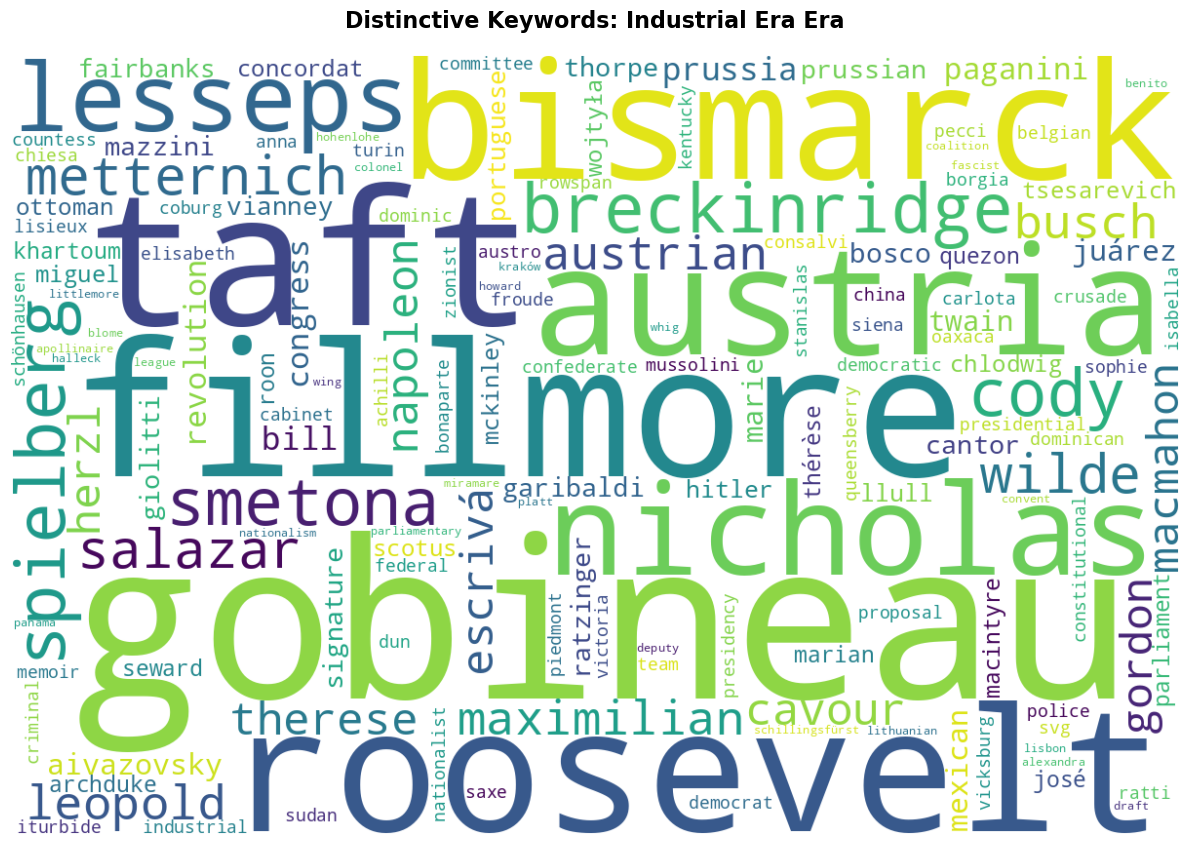

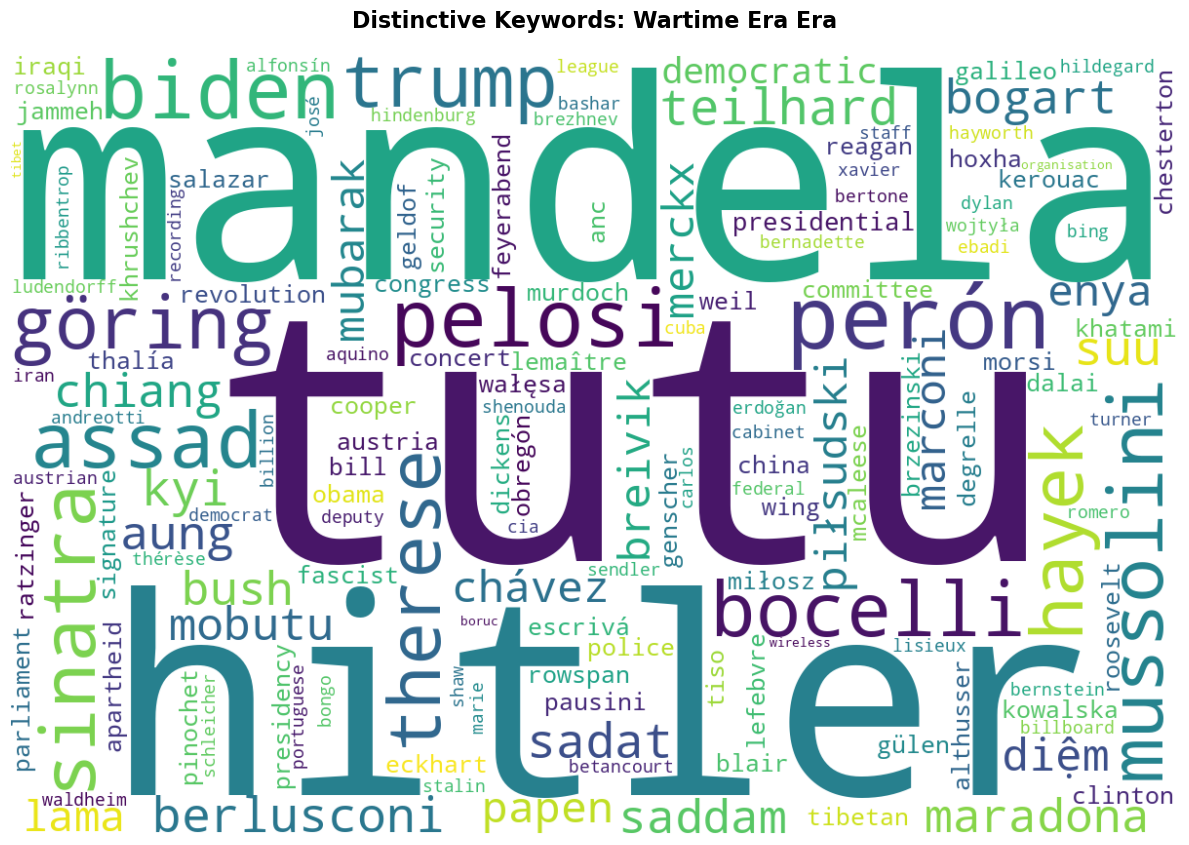

Cannot generate WordCloud: Input weight dictionary is empty.
Cannot generate WordCloud: Input weight dictionary is empty.


In [168]:
visualize_all_pope_eras(popes_in_periods, network)

In [169]:
def compare_2_eras(era1, era2):
    return dict((k,popes_in_periods[k]) for k in (era1, era2) if k in popes_in_periods)

As an experiment, we compare 2 eras below without calculating the TF-IDF for all texts. This means the weights will be slightly different and thus the visualizations will also differ from the full comparison.

Gathering Data
Processing era: Classical Era...
Processing era: Wartime Era...

Computing TF-IDF
Analyzing corpus for frequent terms...
Auto-detected 20840 specific stopwords (appearing in >70% of docs).
Examples removed: ['magie', 'vi', 'succeed', 'misplaced', 'opposing']

Generating Visualizations


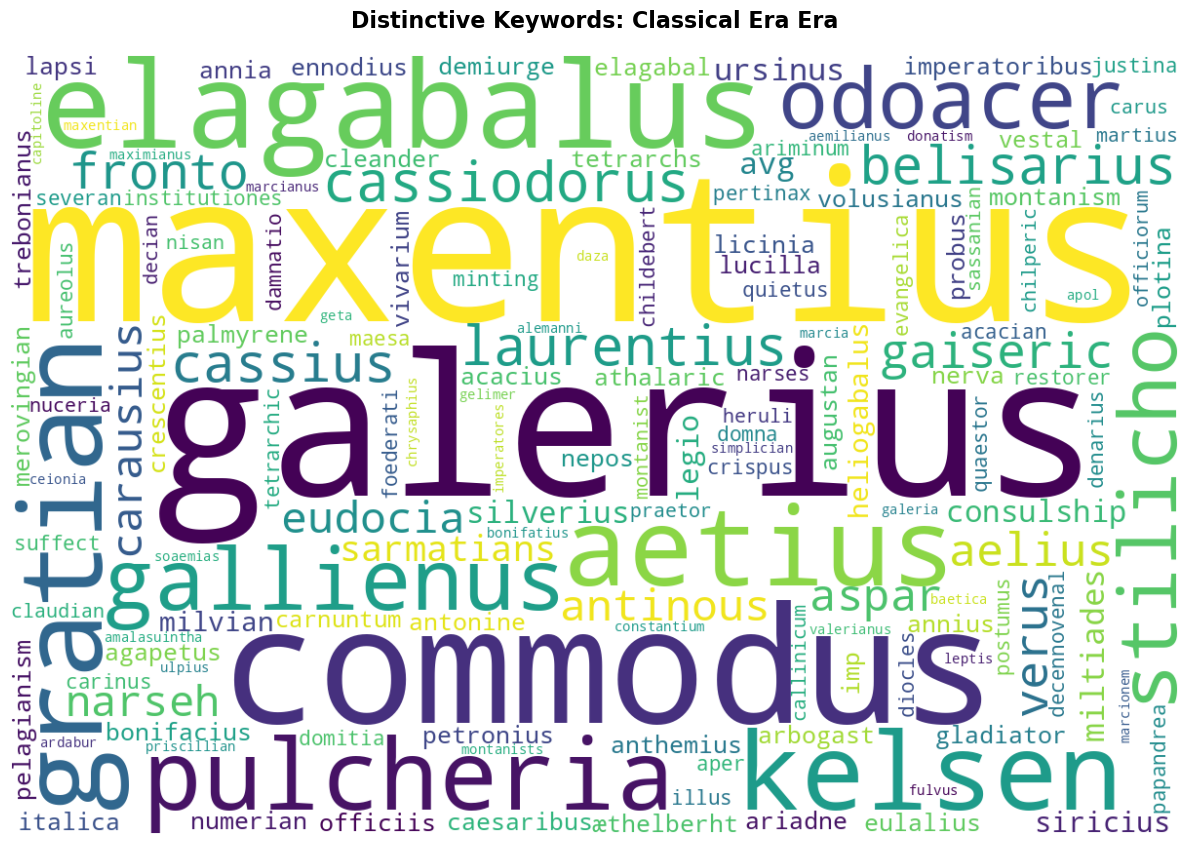

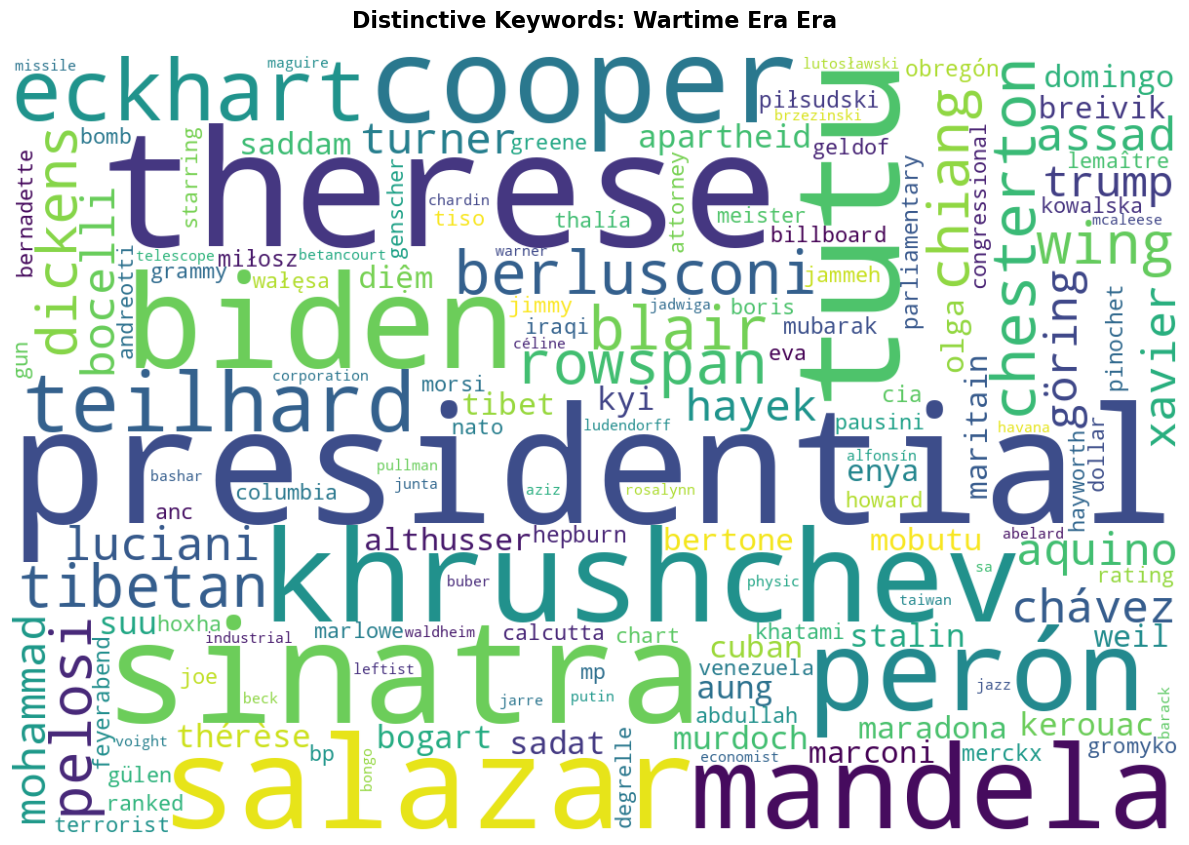

In [173]:
visualize_all_pope_eras(compare_2_eras("Classical Era", "Wartime Era"), network)

In [ ]:
import os
import difflib

folder_path = "wikipages"


def batch_fix_filenames(target_folder, target_names):
    # Get list of files currently on disk
    try:
        files_on_disk = os.listdir(target_folder)
    except FileNotFoundError:
        print(f"Error: Folder '{target_folder}' not found.")
        return

    count_fixed = 0

    for correct_name in target_names:
        correct_filename = f"{correct_name}.txt"
        
        # Check if the clean file already exists
        if correct_filename in files_on_disk:
            # File is already perfect, skip it
            continue
            
        # If not found, look for a "messy" match
        matches = difflib.get_close_matches(correct_filename, files_on_disk, n=1, cutoff=0.6)
        
        if matches:
            messy_filename = matches[0]
            
            # Construct full paths
            old_path = os.path.join(target_folder, messy_filename)
            new_path = os.path.join(target_folder, correct_filename)
            
            try:
                # RENAME THE FILE
                os.rename(old_path, new_path)
                print(f"Fixed: '{messy_filename}'  ->  '{correct_filename}'")
                
                # Update our local list so we don't try to fix it again
                files_on_disk.remove(messy_filename)
                files_on_disk.append(correct_filename)
                count_fixed += 1
                
            except OSError as e:
                print(f"Failed to rename {messy_filename}: {e}")
        else:
            print(f"Could not find any file resembling: {correct_filename}")

    print(f"Complete. Renamed {count_fixed} files.")


We observe that a significant amount of the words related to eras are names. There are a few that are well-known and expected to show up in their respective eras related to Popes such as Gallileo, Nero or Trump. However some names stood out as unexpected "guests". Two that caought our attention were Tutu and Charlemagne. In the following sections we will analyse these characters more deeply to find out more about their roles in this network.

TUTU
occupation': 'RELIGIOUS FIGURE'

In [ ]:
#pope_graph = network.subgraph([n for n, attr in network.nodes(data=True) if (attr.get("occupation") == 'RELIGIOUS FIGURE')])

First we find Desomond Tutu in our network

In [174]:
# Find Desmond Tutu node
tutu_node = None
for node in network.nodes():
    node_name = network.nodes[node].get('Name', '')
    if 'Desmond Tutu' in node_name or 'Tutu' in node_name:
        tutu_node = node
        print(f"Found: {node_name}")
        break

if tutu_node:
    tutu_data = network.nodes[tutu_node]
    print(f"\nDESMOND TUTU")
    print(f"Name: {tutu_data.get('Name')}")
    print(f"Birth Year: {tutu_data.get('birthyear')}")
    print(f"Death Year: {tutu_data.get('deathyear')}")
    print(f"Birth City: {tutu_data.get('birthcity')}")
    print(f"Occupation: {tutu_data.get('occupation')}")


Found: Desmond Tutu

DESMOND TUTU
Name: Desmond Tutu
Birth Year: 1931.0
Death Year: 2018.0
Birth City: KLERKSDORP
Occupation: RELIGIOUS FIGURE


It is important to note that Desmond Tutu died in 2021, our dataset has a cutoff at 2018, so the people alive after 2018 are still shown with 2018 death yer. https://en.wikipedia.org/wiki/Desmond_Tutu

In [175]:
# Analyze Tutu's importance in the network
if tutu_node:
    print(f"\n=== TUTU'S NETWORK METRICS ===")
    print(f"Degree (connections): {network.degree(tutu_node)}")
    print(f"In-Degree: {network.in_degree(tutu_node)}")
    print(f"Out-Degree: {network.out_degree(tutu_node)}")



=== TUTU'S NETWORK METRICS ===
Degree (connections): 57
In-Degree: 29
Out-Degree: 28


Next we try to capture what is the theme around Tutu using the same method as for the popes.

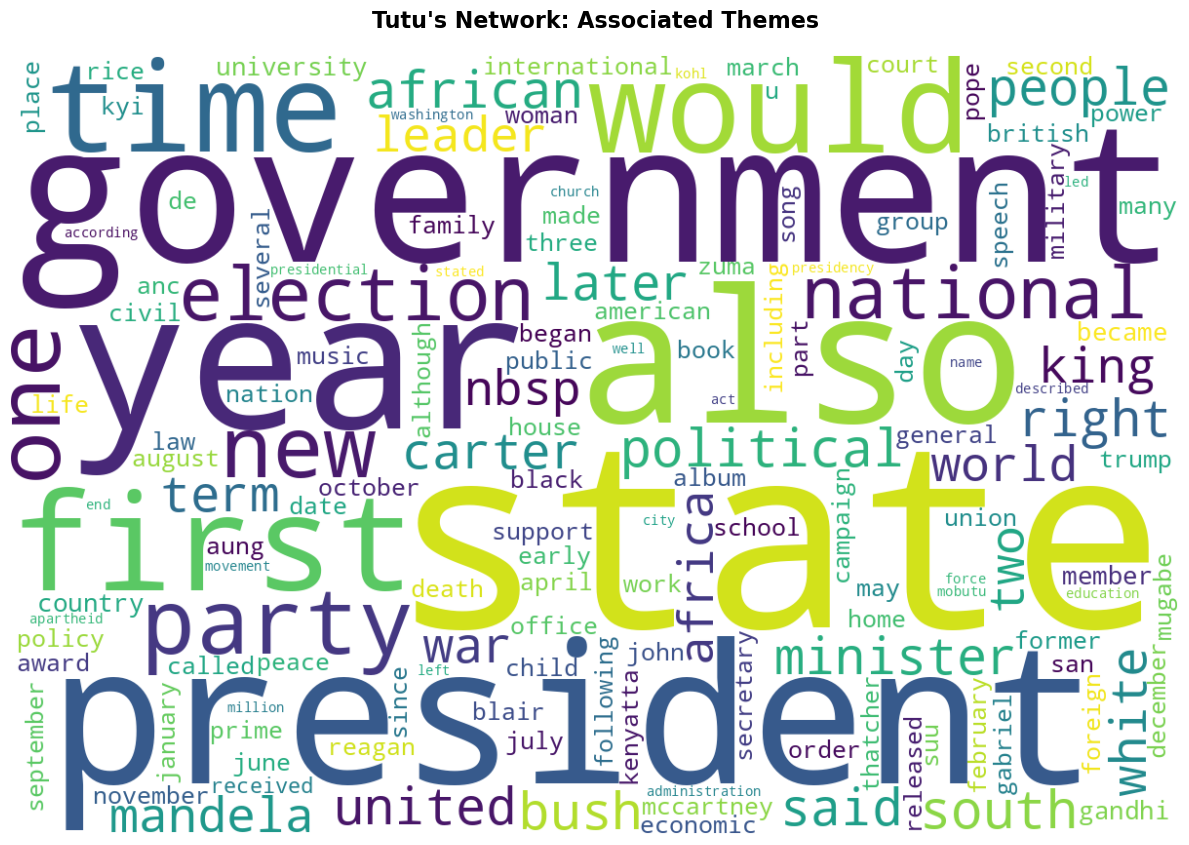

In [ ]:
# Aggregate content from all people connected to Tutu
if tutu_node:
    
    neighbor_tokens = []
    neighbors = get_undirected_neighbors(tutu_node, network)
    
    for neighbor in neighbors:
        content = get_wikilink_content(neighbor, network)
        if content:
            tokens = clean_and_tokenize(content)
            neighbor_tokens += tokens
    
    # Create word cloud
    create_wordcloud_from_tokens(
        neighbor_tokens,
        title="Tutu's Network",
        colormap='viridis'
    )

This yields results as expected. The ties around Africa, state and government show in line with the wikipedia article of Desmond Tutu.

In [ ]:
# Check if Tutu bridges different communities

undirected_net = network.to_undirected()

# Is Tutu an articulation point?
articulation_points = list(nx.articulation_points(undirected_net))
is_bridge = tutu_node in articulation_points

print(f"\nTUTU'S BRIDGE ROLE")
print(f"Is Tutu an articulation point (bridge)? {is_bridge}")

temp_net = undirected_net.copy()
temp_net.remove_node(tutu_node)

components_before = len(list(nx.connected_components(undirected_net)))
components_after = len(list(nx.connected_components(temp_net)))

print(f"\nImpact of removing Tutu:")
print(f"  Components before: {components_before}")
print(f"  Components after: {components_after}")
print(f"  Network would split into {components_after} separate groups")


=== TUTU'S BRIDGE ROLE ===
Is Tutu an articulation point (bridge)? False

Impact of removing Tutu:
  Components before: 233
  Components after: 233
  Network would split into 233 separate groups


Next we analyse the clustering coefficient of Tutu to see if he bridges diverse groups.

In [ ]:

undirected_net = network.to_undirected()

# Get all neighbors
neighbors = get_undirected_neighbors(tutu_node, undirected_net)
print(f"Tutu has {len(neighbors)} direct connections")

# Measure: LOCAL CLUSTERING COEFFICIENT
# Low value = bridges different groups (high value = connected to a tight clique)
clustering_coeff = nx.clustering(undirected_net, tutu_node)
print(f"Clustering Coefficient: {clustering_coeff:.4f}")
print(f"If close to 0: Tutu bridges diverse groups")
print(f"If close to 1: Tutu is in a tight clique")


Tutu has 52 direct connections
Clustering Coefficient: 0.1033
If close to 0: Tutu bridges diverse groups
If close to 1: Tutu is in a tight clique


With a low clustering coefficient Tutu seems to bridge more diverse groups instead of being in a clique.

In [185]:
def get_era(birth_year):
    """Determine which era a birth year belongs to"""
    if birth_year is None:
        return 'Unknown'
    
    try:
        year = int(birth_year)
    except (ValueError, TypeError):
        return 'Unknown'
    
    if year < 30:
        return 'Before Christ (< 30)'
    elif 30 <= year < 476:
        return 'Classical Era (30-476)'
    elif 476 <= year < 1450:
        return 'Middle Ages (476-1450)'
    elif 1450 <= year < 1760:
        return 'Early Modern (1450-1760)'
    elif 1760 <= year < 1840:
        return 'Industrial Era (1760-1840)'
    elif 1840 <= year < 1945:
        return 'Wartime (1840-1945)'
    elif 1945 <= year <= 2025:
        return 'Post-War (1945-2025)'
    else:
        return 'Unknown'

We investigate the neighbors of Tutu more with regards to the eras they lived in and their occupations.

In [ ]:

neighbors = get_undirected_neighbors(tutu_node, network)

print(f"\nTUTU'S NEIGHBOR DIVERSITY\n")

neighbor_occupations = {}
neighbor_eras = {}

for neighbor in neighbors:
    occupation = network.nodes[neighbor].get('occupation', 'Unknown')
    birthyear = network.nodes[neighbor].get('birthyear', 0)
    
    # Count occupations
    neighbor_occupations[occupation] = neighbor_occupations.get(occupation, 0) + 1
    
    era = get_era(birthyear)
        
    neighbor_eras[era] = neighbor_eras.get(era, 0) + 1

print("Occupations of Tutu's neighbors:")
for occ, count in sorted(neighbor_occupations.items(), key=lambda x: x[1], reverse=True):
    print(f"  {occ}: {count}")

print(f"\nHistorical eras of Tutu's neighbors:")
for era, count in sorted(neighbor_eras.items(), key=lambda x: x[1], reverse=True):
    print(f"  {era}: {count}")



TUTU'S NEIGHBOR DIVERSITY

Occupations of Tutu's neighbors:
  POLITICIAN: 29
  SOCIAL ACTIVIST: 9
  RELIGIOUS FIGURE: 3
  MUSICIAN: 3
  BUSINESSPERSON: 2
  SINGER: 2
  ATHLETE: 1
  DIPLOMAT: 1
  ACTOR: 1
  WRITER: 1

Historical eras of Tutu's neighbors:
  Wartime (1840-1945): 33
  Post-War (1945-2025): 18
  Early Modern (1450-1760): 1


As visible most of the neighbors are politicians. This is an interesting finding because he himself is a religious figure. This can be attributed to the human rights activism which was a significant part of his work. Most of his connections are born in the same era as him (his birthyear 1931 is part of the wartime era), this is less surprising.

As we discovered Tutu from the people surrounding the popes a logical next step is to investigate his relationship with all popes in the network.

In [188]:

print(f"TUTU'S CONNECTION TO POPES\n")

# Find all pope nodes
pope_nodes = [
    n for n, attr in network.nodes(data=True)
    if isinstance(attr.get("Name"), str) and "Pope" in attr.get("Name") and 
        attr.get("occupation") == "RELIGIOUS FIGURE"
]

print(f"Total popes in network: {len(pope_nodes)}")

# Check direct connections to popes
neighbors = get_undirected_neighbors(tutu_node, network)
popes_connected_to_tutu = [n for n in neighbors if n in pope_nodes]

print(f"Popes directly connected to Tutu: {len(popes_connected_to_tutu)}")

if popes_connected_to_tutu:
    print("\nDirect pope connections:")
    for pope_node in popes_connected_to_tutu:
        pope_name = network.nodes[pope_node].get('Name')
        pope_year = network.nodes[pope_node].get('birthyear')
        print(f"  - {pope_name} ({pope_year})")

# Check shortest paths from Tutu to each pope
print(f"\nShortest paths from Tutu to popes:")
undirected_net = network.to_undirected()

path_lengths = []
for pope_node in pope_nodes:
    if nx.has_path(undirected_net, tutu_node, pope_node):
        path_length = nx.shortest_path_length(undirected_net, tutu_node, pope_node)
        path_lengths.append(path_length)
        pope_name = network.nodes[pope_node].get('Name')

if path_lengths:
    avg_path_length = sum(path_lengths) / len(path_lengths)
    print(f"\nAverage path length to popes: {avg_path_length:.2f}")
    print(f"Min: {min(path_lengths)}, Max: {max(path_lengths)}")

TUTU'S CONNECTION TO POPES

Total popes in network: 260
Popes directly connected to Tutu: 2

Direct pope connections:
  - Pope Benedict XVI (1927.0)
  - Pope John XXIII (1881.0)

Shortest paths from Tutu to popes:

Average path length to popes: 3.33
Min: 1, Max: 5


We get an average path length of 3.33 which seems small, but is actually in line with a scale-free network. https://networksciencebook.com/chapter/4#ultra-small
It is important to note that the comparison here is just for indication, as we only analyzed average path lengths from a single node to designated other nodes. Based on this there might be people who have a shorter path length to the popes. We are continuing with this direction.

In [189]:
undirected_net = network.to_undirected()

# Get all pope nodes (you already have this)
pope_nodes = [
    n for n, attr in network.nodes(data=True)
    if isinstance(attr.get("Name"), str) and "Pope" in attr.get("Name") and 
        attr.get("occupation") == "RELIGIOUS FIGURE"
]

In [ ]:
import pandas as pd
import networkx as nx

print(f"SHORTEST PATHS TO POPES\n")
print(f"Analyzing {network.number_of_nodes()} nodes...")
print(f"Target: {len(pope_nodes)} popes\n")

path_stats = []

# GATHER DATA
for node in network.nodes():
    node_data = network.nodes[node]
    node_name = node_data.get('Name', 'Unknown')
    occupation = node_data.get('occupation', 'Unknown')
    
    # Filter
    if occupation == "RELIGIOUS FIGURE":
        continue
    
    # Calculate paths
    path_lengths = []
    for pope_node in pope_nodes:
        if nx.has_path(undirected_net, node, pope_node):
            path_len = nx.shortest_path_length(undirected_net, node, pope_node)
            path_lengths.append(path_len)
    
    # Store valid data
    if path_lengths and len(path_lengths) >= 5:
        avg_path = sum(path_lengths) / len(path_lengths)
        
        path_stats.append({
            'Rank': 0, # Placeholder
            'Name': node_name,
            'Occupation': occupation,
            'Avg Path': round(avg_path, 2),
            'Reachable': len(path_lengths),
            'Min': min(path_lengths),
            'Max': max(path_lengths)
        })


df = pd.DataFrame(path_stats)

# Sort by Average Path
df = df.sort_values(by='Avg Path', ascending=True)
df['Rank'] = range(1, len(df) + 1)


cols = ['Rank', 'Name', 'Occupation', 'Avg Path', 'Reachable', 'Min', 'Max']
df = df[cols]

print(f"Found {len(df)} non-religious figures connected to popes\n")

# Print the top 30
print(df.head(5).to_string(index=False))

SHORTEST PATHS TO POPES

Analyzing 11286 nodes...
Target: 260 popes

Found 10513 non-religious figures connected to popes

 Rank                          Name  Occupation  Avg Path  Reachable  Min  Max
    1            Augustine of Hippo PHILOSOPHER      2.48        260    1    4
    2                   Charlemagne  POLITICIAN      2.51        260    1    4
    3                Thomas Aquinas PHILOSOPHER      2.51        260    1    4
    4                          Bede   HISTORIAN      2.52        260    1    4
    5                        Origen PHILOSOPHER      2.62        260    1    4
    6               Dante Alighieri      WRITER      2.69        260    1    4
    7                     Aristotle PHILOSOPHER      2.72        260    1    4
    8                        Virgil      WRITER      2.75        260    1    4
    9                 Constantine I  POLITICIAN      2.76        260    1    4
   10                         Plato PHILOSOPHER      2.77        260    1    4
   11   

We find here that Charlemagne who we found previously with the wordclouds is also present here as one of the people with the shortest paths to the popes. We go deeper into his statistics.

In [194]:

target_name = "Charlemagne"


target_stat = next((stat for stat in path_stats if stat['Name'] == target_name), None)

print(f"Average path to popes: {target_stat['Avg Path']:.2f} hops")
print(f"Can reach: {target_stat['Reachable']}/{len(pope_nodes)} popes")
print(f"Closest pope: {target_stat['Min']} hops away")
print(f"Farthest pope: {target_stat['Max']} hops away")

Average path to popes: 2.51 hops
Can reach: 260/260 popes
Closest pope: 1 hops away
Farthest pope: 4 hops away


In [183]:
# ...existing code...

import statistics
from networkx.algorithms import approximation as approx
from networkx.algorithms.centrality import betweenness_centrality_subset

def node_pope_distance_stats(G, node, pope_nodes):
    # returns dictionary of metrics of distances from node to pope_nodes
    dists = []
    for p in pope_nodes:
        try:
            d = nx.shortest_path_length(G, node, p)
            dists.append(d)
        except nx.NetworkXNoPath:
            continue
    if not dists:
        return None
    return {
        'count_reachable': len(dists),
        'mean': statistics.mean(dists),
        'median': statistics.median(dists),
        'min': min(dists),
        'max': max(dists),
        'harmonic_mean': len(dists) / sum(1.0/d for d in dists),
        'within_2': sum(1 for d in dists if d <= 2),
        'within_3': sum(1 for d in dists if d <= 3),
    }

# 1) compute refined distance stats for non-religious nodes and rank by mean (or harmonic mean)
undirected_net = network.to_undirected()
pope_nodes = [n for n, a in network.nodes(data=True) if isinstance(a.get("Name"), str) and "Pope" in a.get("Name") and a.get("occupation") == "RELIGIOUS FIGURE"]

candidates = []
for node, attr in network.nodes(data=True):
    if attr.get('occupation') == 'RELIGIOUS FIGURE':
        continue
    stats = node_pope_distance_stats(undirected_net, node, pope_nodes)
    if stats and stats['count_reachable'] >= 5:   # require reaching multiple popes
        candidates.append({'node': node, 'name': attr.get('Name'), **stats})

# sort by harmonic mean (more robust to outliers / unreachable)
candidates.sort(key=lambda x: x['harmonic_mean'])
print("Top candidates by harmonic mean distance to popes:")
for c in candidates[:30]:
    print(f"{c['name'][:50]:50} mean:{c['mean']:.2f} harm:{c['harmonic_mean']:.2f} reach:{c['count_reachable']} within2:{c['within_2']}")

# 2) betweenness restricted to pope↔pope shortest paths (who sits on pope<>pope geodesics)
# use betweenness_centrality_subset: sources=pope_nodes, targets=pope_nodes (may be heavy)
print("\nComputing pope↔pope betweenness (subset). This can be slow.")
pope_pair_betw = betweenness_centrality_subset(undirected_net, sources=pope_nodes, targets=pope_nodes, normalized=False)
# report top non-religious brokers on pope↔pope paths
top_brokers = sorted(((n, v) for n, v in pope_pair_betw.items() if network.nodes[n].get('occupation') != 'RELIGIOUS FIGURE'), key=lambda x: x[1], reverse=True)
print("\nTop non-religious nodes on pope↔pope shortest paths:")
for n, v in top_brokers[:30]:
    print(f"{network.nodes[n].get('Name')[:50]:50} count:{v:.0f} deg:{undirected_net.degree(n)}")



Top candidates by harmonic mean distance to popes:
Augustine of Hippo                                 mean:2.48 harm:2.25 reach:260 within2:137
Thomas Aquinas                                     mean:2.51 harm:2.25 reach:260 within2:131
Charlemagne                                        mean:2.51 harm:2.33 reach:260 within2:124
Bede                                               mean:2.52 harm:2.37 reach:260 within2:123
Origen                                             mean:2.62 harm:2.44 reach:260 within2:103
Dante Alighieri                                    mean:2.69 harm:2.53 reach:260 within2:89
Aristotle                                          mean:2.72 harm:2.56 reach:260 within2:94
Henry II, Holy Roman Emperor                       mean:2.82 harm:2.57 reach:260 within2:78
Justinian I                                        mean:2.78 harm:2.59 reach:260 within2:73
Athanasius of Alexandria                           mean:2.79 harm:2.60 reach:260 within2:72
Virgil                  

Finally we are also curious about people who bridge different eras in line with our era definitions. We look at the connections to see which eras they are from.

In [195]:
# Find nodes that bridge the most ERAS (temporal bridges)
print("ERA BRIDGES: People Who Connect Different Historical Periods")

# For each node, find which eras its neighbors belong to
undirected_net = network.to_undirected()
era_bridges = []

for node in network.nodes():
    node_name = network.nodes[node].get('Name', 'Unknown')
    node_birth = network.nodes[node].get('birthyear')
    node_era = get_era(node_birth)
    node_occupation = network.nodes[node].get('occupation', 'Unknown')
    
    # Get all neighbors
    try:
        neighbors = get_undirected_neighbors(node, undirected_net)
    except:
        continue
    
    if not neighbors:
        continue
    
    # Find which eras the neighbors belong to
    neighbor_eras = set()
    for neighbor in neighbors:
        neighbor_birth = network.nodes[neighbor].get('birthyear')
        neighbor_era = get_era(neighbor_birth)
        if neighbor_era != 'Unknown':
            neighbor_eras.add(neighbor_era)
    
    # Only include nodes that bridge 2+ eras
    if len(neighbor_eras) >= 2:
        era_bridges.append({
            'node_id': node,
            'name': node_name,
            'occupation': node_occupation,
            'birth_era': node_era,
            'birth_year': node_birth,
            'eras_spanned': neighbor_eras,
            'num_eras': len(neighbor_eras),
            'degree': len(neighbors),
            'neighbors_per_era': {era: sum(1 for nb in neighbors if get_era(network.nodes[nb].get('birthyear')) == era) for era in neighbor_eras}
        })

ERA BRIDGES: People Who Connect Different Historical Periods


In [196]:


# Sort by number of eras spanned
era_bridges.sort(key=lambda x: x['num_eras'], reverse=True)

print(f"\nFound {len(era_bridges)} people who bridge across multiple eras\n")
print(f"{'Rank':<6} {'Name':<40} {'Birth Era':<35} {'Eras Spanned':<6} {'Degree':<8} {'Occupation':<25}")
print("-" * 130)

for rank, bridge in enumerate(era_bridges[:40], 1):
    eras_str = str(bridge['num_eras'])
    print(f"{rank:<6} {bridge['name'][:38]:<40} {str(bridge['birth_era'])[:33]:<35} "
          f"{eras_str:<6} {bridge['degree']:<8} {bridge['occupation'][:23]:<25}")

# Deep dive into top era bridges
print(f"\n{'='*120}")
print("TOP 5 ERA BRIDGES - DETAILED ANALYSIS")
print(f"{'='*120}")

for rank, bridge in enumerate(era_bridges[:5], 1):
    print(f"\n{'='*120}")
    print(f"RANK {rank}: {bridge['name']}")
    print(f"{'='*120}")
    print(f"Birth Year: {bridge['birth_year']}")
    print(f"Birth Era: {bridge['birth_era']}")
    print(f"Occupation: {bridge['occupation']}")
    print(f"Total Connections: {bridge['degree']}")
    print(f"\nEras Connected ({bridge['num_eras']} total):")
    
    for era in sorted(bridge['eras_spanned']):
        count = bridge['neighbors_per_era'][era]
        print(f"  - {era:<35} : {count:>3} connections")
    
    # Show sample neighbors from each era
    print(f"\nSample neighbors from each era:")
    for era in sorted(bridge['eras_spanned']):
        neighbors = get_undirected_neighbors(bridge['node_id'], undirected_net)
        era_neighbors = [nb for nb in neighbors if get_era(network.nodes[nb].get('birthyear')) == era]
        sample = era_neighbors[:3]
        print(f"\n  {era}:")
        for neighbor_id in sample:
            neighbor_name = network.nodes[neighbor_id].get('Name', 'Unknown')
            neighbor_year = network.nodes[neighbor_id].get('birthyear')
            print(f"    - {neighbor_name} ({int(neighbor_year) if neighbor_year else 'Unknown'})")

# Find the most "temporally distant" connections
print(f"\n{'='*120}")
print("TEMPORAL DISTANCE ANALYSIS: Who Bridges the Largest Time Gaps?")
print(f"{'='*120}")

temporal_bridges = []

for node in network.nodes():
    node_name = network.nodes[node].get('Name', 'Unknown')
    node_birth = network.nodes[node].get('birthyear')
    node_occupation = network.nodes[node].get('occupation', 'Unknown')
    
    try:
        neighbors = get_undirected_neighbors(node, undirected_net)
    except:
        continue
    
    if len(neighbors) < 2:
        continue
    
    # Get birth years of all neighbors
    neighbor_years = []
    for neighbor in neighbors:
        nb_year = network.nodes[neighbor].get('birthyear')
        if nb_year and isinstance(nb_year, (int, float)):
            neighbor_years.append(float(nb_year))
    
    if len(neighbor_years) >= 2:
        time_span = max(neighbor_years) - min(neighbor_years)
        avg_time_gap = time_span / len(neighbor_years)
        
        temporal_bridges.append({
            'node_id': node,
            'name': node_name,
            'occupation': node_occupation,
            'birth_year': node_birth,
            'time_span': time_span,
            'avg_gap': avg_time_gap,
            'degree': len(neighbors),
            'earliest_neighbor': min(neighbor_years),
            'latest_neighbor': max(neighbor_years)
        })

temporal_bridges.sort(key=lambda x: x['time_span'], reverse=True)

print(f"\nTop people bridging the largest time gaps:\n")
print(f"{'Rank':<6} {'Name':<40} {'Birth Year':<12} {'Time Span':<12} {'Degree':<8} {'Earliest→Latest':<25} {'Occupation':<20}")
print("-" * 140)

for rank, bridge in enumerate(temporal_bridges[:30], 1):
    time_span_str = f"{int(bridge['time_span'])} yrs"
    earliest = int(bridge['earliest_neighbor']) if bridge['earliest_neighbor'] else '?'
    latest = int(bridge['latest_neighbor']) if bridge['latest_neighbor'] else '?'
    gap_str = f"{earliest} → {latest}"
    
    print(f"{rank:<6} {bridge['name'][:38]:<40} {int(bridge['birth_year']) if bridge['birth_year'] else '?':<12} "
          f"{time_span_str:<12} {bridge['degree']:<8} {gap_str:<25} {bridge['occupation'][:18]:<20}")

# Find religious figures who bridge eras (interesting case)
print(f"\n{'='*120}")
print("RELIGIOUS FIGURES AS ERA BRIDGES")
print(f"{'='*120}")

religious_era_bridges = [b for b in era_bridges if b['occupation'] == 'RELIGIOUS FIGURE']
religious_era_bridges.sort(key=lambda x: x['num_eras'], reverse=True)

print(f"\nFound {len(religious_era_bridges)} religious figures who bridge multiple eras\n")

if religious_era_bridges:
    print(f"{'Rank':<6} {'Name':<40} {'Birth Era':<35} {'Eras Spanned':<12} {'Degree':<8}")
    print("-" * 110)
    
    for rank, bridge in enumerate(religious_era_bridges[:20], 1):
        print(f"{rank:<6} {bridge['name'][:38]:<40} {str(bridge['birth_era'])[:33]:<35} "
              f"{bridge['num_eras']:<12} {bridge['degree']:<8}")


Found 7846 people who bridge across multiple eras

Rank   Name                                     Birth Era                           Eras Spanned Degree   Occupation               
----------------------------------------------------------------------------------------------------------------------------------
1      Zoroaster                                Before Christ (< 30)                7      49       WRITER                   
2      Jacques Derrida                          Wartime (1840-1945)                 7      60       PHILOSOPHER              
3      Charlemagne                              Middle Ages (476-1450)              7      99       POLITICIAN               
4      Mao Zedong                               Wartime (1840-1945)                 7      98       POLITICIAN               
5      Søren Kierkegaard                        Industrial Era (1760-1840)          7      69       PHILOSOPHER              
6      Cleopatra VII of Egypt                   Before 